# 🌲 Customer Status Prediction — Random Forest Only
**Target:** `Customer_Status` → Churned / Joined / Stayed

> Upload `Customer_Data.csv` via the 📁 Files panel before running

## 📦 Step 1 — Install & Import

In [1]:
!pip install imbalanced-learn --quiet

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 📂 Step 2 — Load Data

In [2]:
df = pd.read_csv('Customer_Data.csv')
print(f'Shape: {df.shape}')
print(f'\nTarget Distribution:')
print(df['Customer_Status'].value_counts())
df.head()

Shape: (6418, 32)

Target Distribution:
Customer_Status
Stayed     4275
Churned    1732
Joined      411
Name: count, dtype: int64


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DEL,Male,35,No,Delhi,7,27,NaN,Yes,No,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,58353-MAH,Female,45,Yes,Maharashtra,14,13,NaN,Yes,Yes,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,25063-WES,Male,51,No,West Bengal,4,35,Deal 5,Yes,No,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,59787-KAR,Male,79,No,Karnataka,3,21,Deal 4,Yes,No,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,28544-TAM,Female,80,No,Tamil Nadu,3,8,NaN,Yes,No,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


## 🔎 Step 3 — Quick EDA

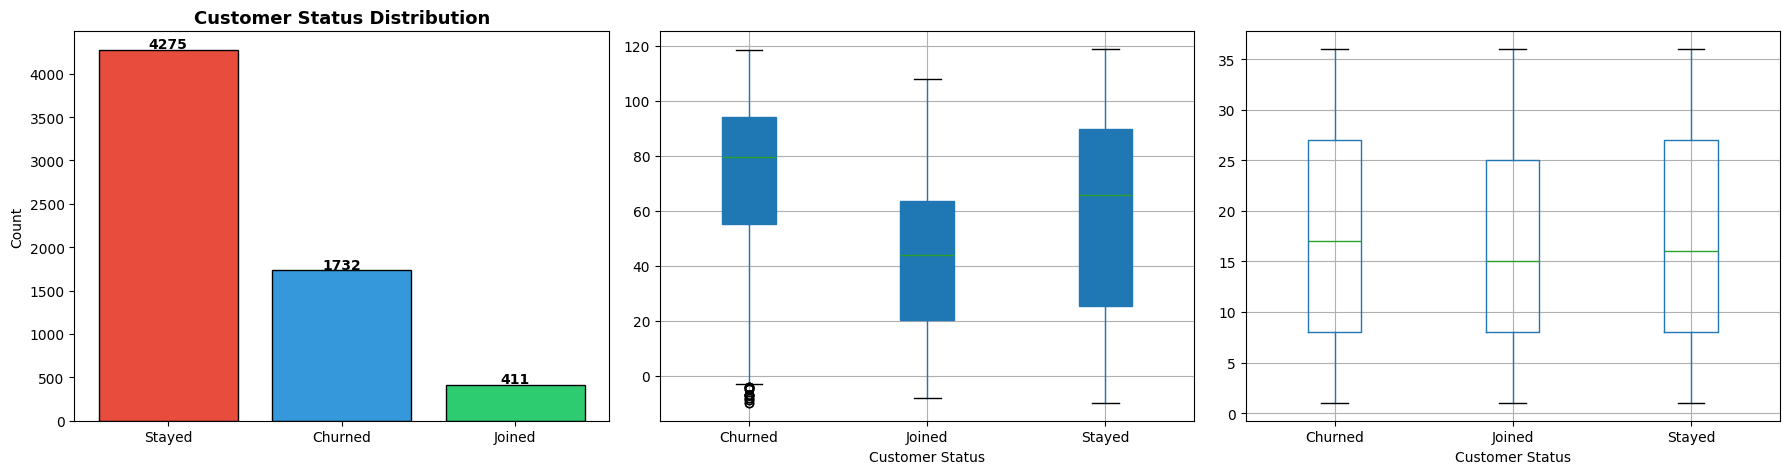

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Class distribution
counts = df['Customer_Status'].value_counts()
colors = ['#e74c3c','#3498db','#2ecc71']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
axes[0].set_title('Customer Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i,(k,v) in enumerate(counts.items()):
    axes[0].text(i, v+20, str(v), ha='center', fontweight='bold')

# Monthly Charge boxplot
df.boxplot(column='Monthly_Charge', by='Customer_Status', ax=axes[1], patch_artist=True)
axes[1].set_title('Monthly Charge by Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Customer Status')
plt.sca(axes[1]); plt.title('')

# Tenure boxplot
df.boxplot(column='Tenure_in_Months', by='Customer_Status', ax=axes[2])
axes[2].set_title('Tenure by Status', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Customer Status')
plt.sca(axes[2]); plt.title('')

plt.suptitle('')
plt.tight_layout()
plt.show()

## 🧹 Step 4 — Preprocessing

In [4]:
# Drop ID and leakage columns
drop_cols = ['Customer_ID', 'Churn_Category', 'Churn_Reason']
df_clean  = df.drop(columns=drop_cols)

X = df_clean.drop(columns=['Customer_Status'])
y = df_clean['Customer_Status']

# Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)
print(f'Target Classes: {le_target.classes_}')

# Fill missing values
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna(X[col].mode()[0])
for col in X.select_dtypes(include=np.number).columns:
    X[col] = X[col].fillna(X[col].median())

# Label encode categoricals
X_enc = X.copy()
for col in X_enc.select_dtypes(include='object').columns:
    X_enc[col] = LabelEncoder().fit_transform(X_enc[col].astype(str))

print(f'Feature shape after encoding: {X_enc.shape}')
print(f'Missing values: {X_enc.isnull().sum().sum()}')

Target Classes: ['Churned' 'Joined' 'Stayed']
Feature shape after encoding: (6418, 28)
Missing values: 0


In [5]:
# Train / Test Split (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_enc, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (5134, 28) | Test: (1284, 28)


## 🌲 Step 5 — Random Forest (Default)

In [6]:
rf_default = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_default.fit(X_train, y_train)
y_pred_default = rf_default.predict(X_test)

print('='*55)
print('   Random Forest — Default Settings')
print('='*55)
print(f'Test Accuracy  : {accuracy_score(y_test, y_pred_default):.4f}')
print(f'F1 Weighted    : {f1_score(y_test, y_pred_default, average="weighted"):.4f}')
print(f'F1 Macro       : {f1_score(y_test, y_pred_default, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_default, target_names=le_target.classes_))

   Random Forest — Default Settings
Test Accuracy  : 0.8092
F1 Weighted    : 0.7980
F1 Macro       : 0.6960

              precision    recall  f1-score   support

     Churned       0.70      0.54      0.61       347
      Joined       0.66      0.52      0.59        82
      Stayed       0.85      0.95      0.90       855

    accuracy                           0.81      1284
   macro avg       0.74      0.67      0.70      1284
weighted avg       0.80      0.81      0.80      1284



## 🔁 Step 6 — 5-Fold Cross Validation

5-Fold Cross Validation Results:
  Fold 1: 0.8232
  Fold 2: 0.7944
  Fold 3: 0.8263
  Fold 4: 0.8129
  Fold 5: 0.8262

  Mean : 0.8166
  Std  : 0.0121


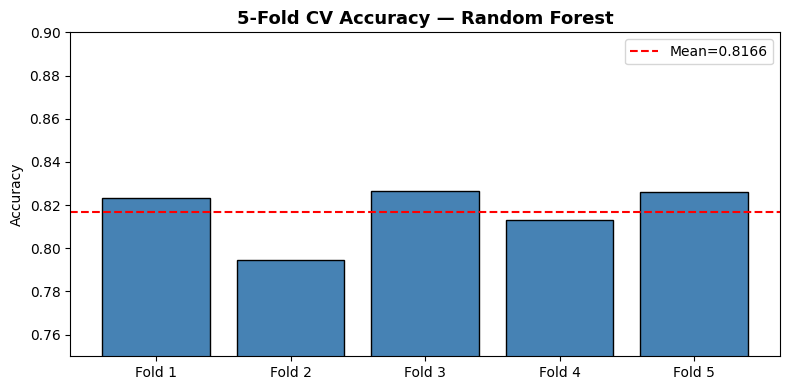

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_default, X_enc, y_enc, cv=cv, scoring='accuracy', n_jobs=-1)

print('5-Fold Cross Validation Results:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean : {cv_scores.mean():.4f}')
print(f'  Std  : {cv_scores.std():.4f}')

# Plot CV scores
plt.figure(figsize=(8, 4))
plt.bar([f'Fold {i}' for i in range(1,6)], cv_scores, color='steelblue', edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean={cv_scores.mean():.4f}')
plt.title('5-Fold CV Accuracy — Random Forest', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy')
plt.ylim([0.75, 0.90])
plt.legend()
plt.tight_layout()
plt.show()

## 🔧 Step 7 — Hyperparameter Tuning (GridSearchCV)

In [8]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)
grid.fit(X_train, y_train)

print(f'\n✅ Best Parameters : {grid.best_params_}')
print(f'✅ Best CV Accuracy : {grid.best_score_:.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits

✅ Best Parameters : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
✅ Best CV Accuracy : 0.8175


In [9]:
# Evaluate tuned model
best_rf = grid.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print('='*55)
print('   Random Forest — Tuned (Best Model)')
print('='*55)
print(f'Test Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Weighted    : {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print(f'F1 Macro       : {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print()
print(classification_report(y_test, y_pred_tuned, target_names=le_target.classes_))

   Random Forest — Tuned (Best Model)
Test Accuracy  : 0.8154
F1 Weighted    : 0.8040
F1 Macro       : 0.7064

              precision    recall  f1-score   support

     Churned       0.72      0.54      0.62       347
      Joined       0.69      0.54      0.60        82
      Stayed       0.85      0.95      0.90       855

    accuracy                           0.82      1284
   macro avg       0.75      0.68      0.71      1284
weighted avg       0.80      0.82      0.80      1284



## 📊 Step 8 — Confusion Matrix & Feature Importance

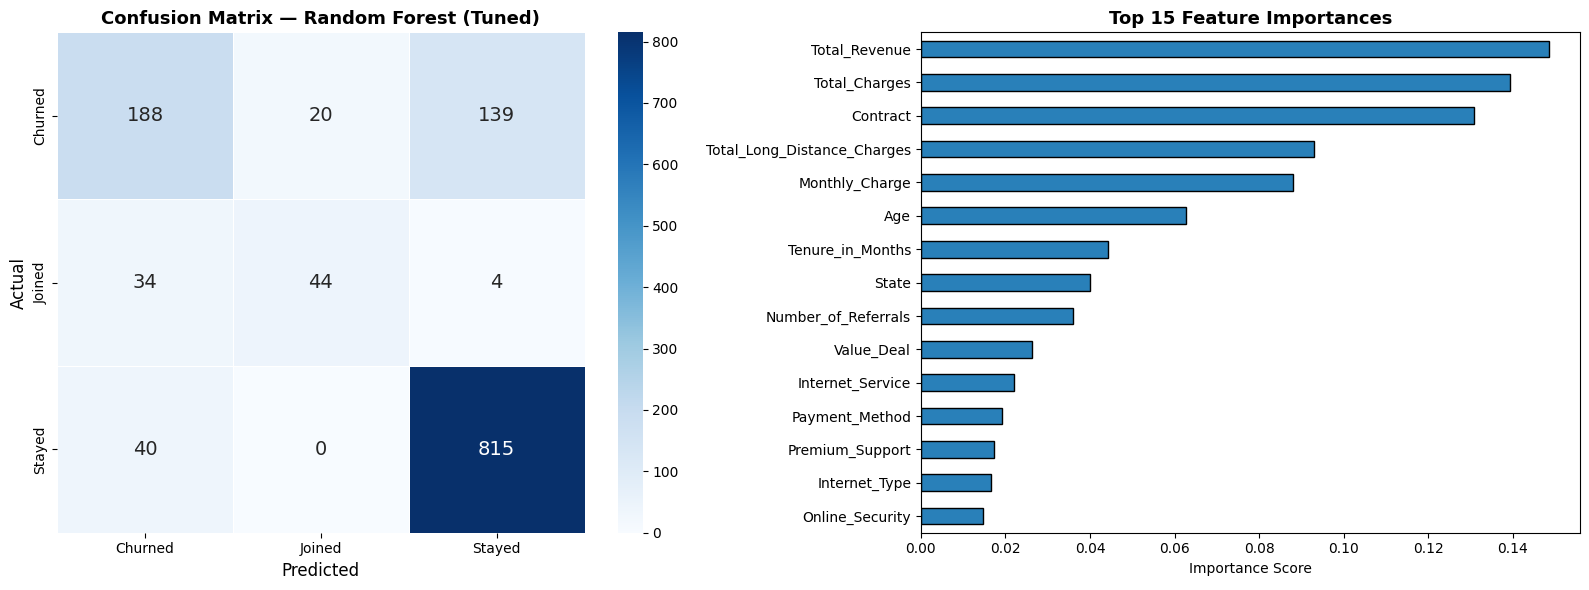

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Confusion Matrix ──
cm = confusion_matrix(y_test, y_pred_tuned)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, annot_kws={'size':14}, ax=axes[0])
axes[0].set_title('Confusion Matrix — Random Forest (Tuned)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].set_xlabel('Predicted', fontsize=12)

# ── Feature Importance ──
feat_imp = pd.Series(best_rf.feature_importances_, index=X_enc.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)
feat_imp.plot(kind='barh', color='#2980b9', edgecolor='black', ax=axes[1])
axes[1].set_title('Top 15 Feature Importances', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 🔮 Step 9 — Predict New Customers

In [11]:
# Predict on first 10 test samples
sample     = X_test.iloc[:10]
preds      = best_rf.predict(sample)
probs      = best_rf.predict_proba(sample)
actuals    = le_target.inverse_transform(y_test[:10])
pred_labels= le_target.inverse_transform(preds)

print('='*60)
print('       PREDICTIONS — First 10 Test Customers')
print('='*60)
print(f'{"Row":<5} {"Actual":<12} {"Predicted":<12} {"Confidence":<12} {"Match"}')
print('-'*60)
for i, (act, pred, prob) in enumerate(zip(actuals, pred_labels, probs)):
    conf  = prob.max() * 100
    match = '✅' if act == pred else '❌'
    print(f'{i+1:<5} {act:<12} {pred:<12} {conf:<11.1f}% {match}')
print('='*60)

       PREDICTIONS — First 10 Test Customers
Row   Actual       Predicted    Confidence   Match
------------------------------------------------------------
1     Stayed       Stayed       65.8       % ✅
2     Churned      Churned      72.8       % ✅
3     Churned      Churned      74.1       % ✅
4     Joined       Joined       54.2       % ✅
5     Churned      Churned      74.6       % ✅
6     Churned      Stayed       51.0       % ❌
7     Churned      Churned      67.1       % ✅
8     Stayed       Stayed       95.6       % ✅
9     Churned      Churned      83.9       % ✅
10    Stayed       Stayed       91.6       % ✅


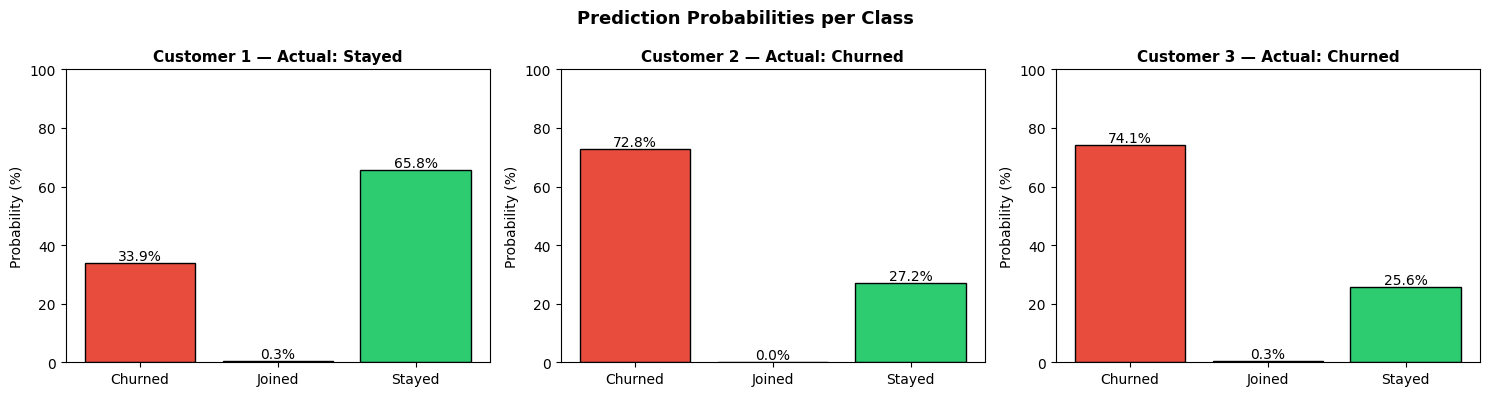

In [12]:
# Predict probability bar chart for first 3 customers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axes[i].bar(le_target.classes_, probs[i]*100,
                color=['#e74c3c','#3498db','#2ecc71'], edgecolor='black')
    axes[i].set_title(f'Customer {i+1} — Actual: {actuals[i]}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Probability (%)')
    axes[i].set_ylim([0, 100])
    for j, v in enumerate(probs[i]*100):
        axes[i].text(j, v+1, f'{v:.1f}%', ha='center', fontsize=10)
plt.suptitle('Prediction Probabilities per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 📋 Step 10 — Final Summary

In [13]:
print('='*55)
print('         🌲 RANDOM FOREST — FINAL SUMMARY')
print('='*55)
print(f'  Dataset Size       : {df.shape[0]} rows × {df.shape[1]} cols')
print(f'  Features Used      : {X_enc.shape[1]}')
print(f'  Train / Test Split : 80% / 20%')
print(f'  Best Params        : {grid.best_params_}')
print(f'  CV Accuracy        : {grid.best_score_:.4f}')
print(f'  Test Accuracy      : {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'  F1 Weighted        : {f1_score(y_test, y_pred_tuned, average="weighted"):.4f}')
print(f'  F1 Macro           : {f1_score(y_test, y_pred_tuned, average="macro"):.4f}')
print('='*55)
print('\n  Top 5 Most Important Features:')
feat_imp_all = pd.Series(best_rf.feature_importances_, index=X_enc.columns)
for rank, (feat, imp) in enumerate(feat_imp_all.sort_values(ascending=False).head(5).items(), 1):
    print(f'    {rank}. {feat:<30} {imp:.4f}')
print('='*55)

         🌲 RANDOM FOREST — FINAL SUMMARY
  Dataset Size       : 6418 rows × 32 cols
  Features Used      : 28
  Train / Test Split : 80% / 20%
  Best Params        : {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 300}
  CV Accuracy        : 0.8175
  Test Accuracy      : 0.8154
  F1 Weighted        : 0.8040
  F1 Macro           : 0.7064

  Top 5 Most Important Features:
    1. Total_Revenue                  0.1485
    2. Total_Charges                  0.1394
    3. Contract                       0.1308
    4. Total_Long_Distance_Charges    0.0931
    5. Monthly_Charge                 0.0881


In [18]:
# ==========================================
# Save Random Forest Model
# ==========================================
import pickle

with open("customer_churn_model.pkl", "wb") as file:
    pickle.dump(rf_default, file)

print("✅ Model saved successfully!")

# ==========================================
# Save Label Encoder
# ==========================================
with open("label_encoder.pkl", "wb") as file:
    pickle.dump(le_target, file)

print("✅ Label Encoder saved successfully!")

# ==========================================
# Save Feature Column Names
# ==========================================
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(X_train.columns.tolist(), file)

print("✅ Feature Columns saved successfully!")

✅ Model saved successfully!
✅ Label Encoder saved successfully!
✅ Feature Columns saved successfully!
